            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


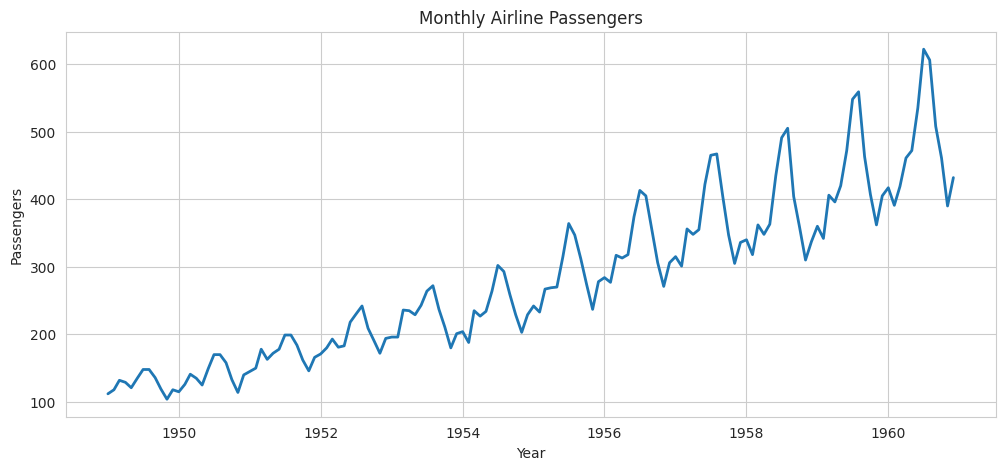

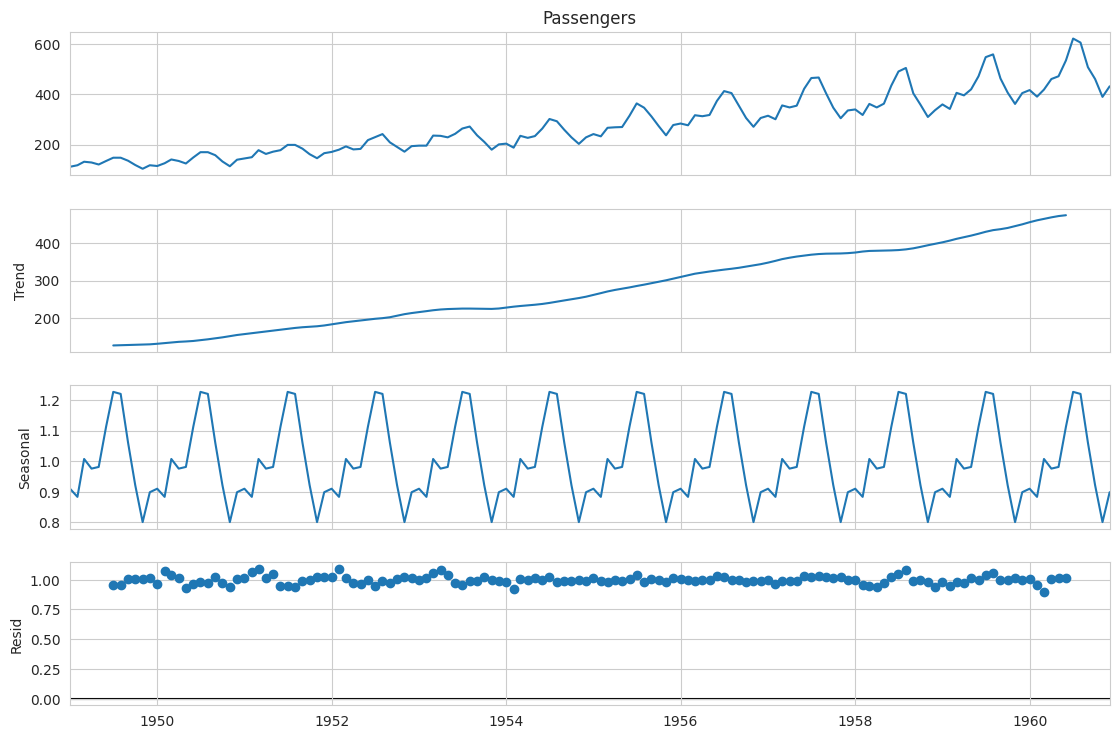


ADF Test - Original Airline Data
ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Used Lags: 13
Number of Observations: 130

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598

Conclusion: Fail to Reject Null Hypothesis
The time series is NOT stationary.


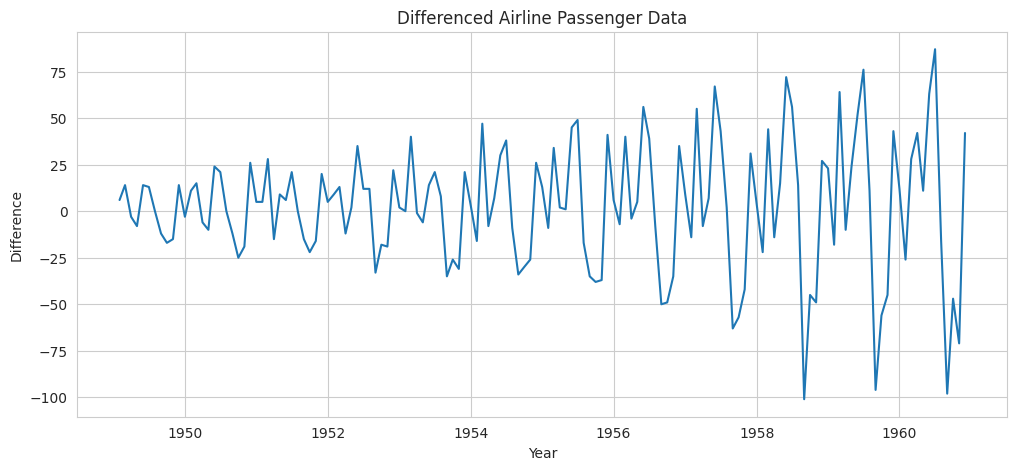


ADF Test - Differenced Airline Data
ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478
Used Lags: 12
Number of Observations: 130

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598

Conclusion: Fail to Reject Null Hypothesis
The time series is NOT stationary.


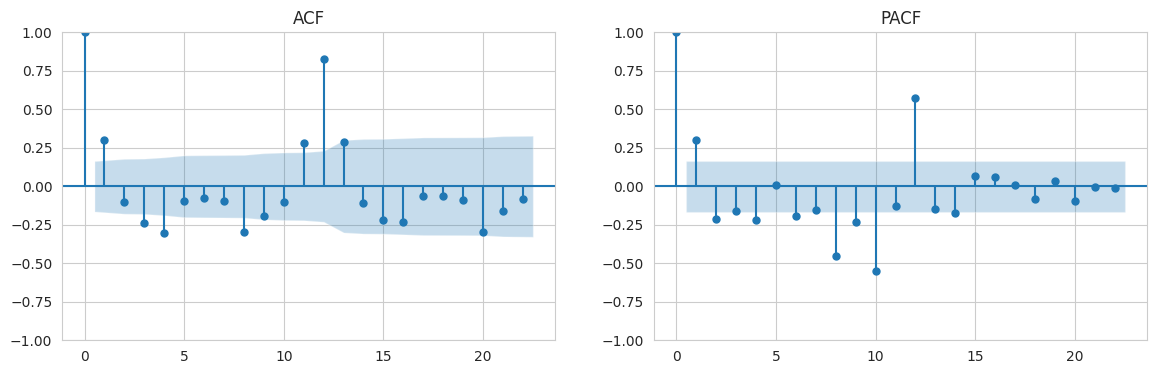


Final dataframe:


,Passengers,Passengers_diff
Month,,
1949-01-01,112,NaN
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0
1949-06-01,135,14.0
1949-07-01,148,13.0
1949-08-01,148,0.0
1949-09-01,136,-12.0


In [1]:
# Airline Time Series Analysis + Augmented Dickey-Fuller Test

import sys
import subprocess

for package in ["pandas", "numpy", "matplotlib", "statsmodels", "seaborn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")


# Load Airline Passenger Dataset


url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.columns = ["Month", "Passengers"]

df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

print(df.head())
print("\nDataset info:")
print(df.info())



# Plot Original Data


plt.figure(figsize=(12,5))
plt.plot(df["Passengers"], linewidth=2)
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()



# Seasonal Decomposition


decomposition = seasonal_decompose(
    df["Passengers"],
    model="multiplicative",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()



# Augmented Dickey-Fuller Test Function


def adf_test(series, title="ADF Test"):

    print("\n" + "="*50)
    print(title)
    print("="*50)

    result = adfuller(series.dropna())

    labels = [
        "ADF Statistic",
        "p-value",
        "Used Lags",
        "Number of Observations"
    ]

    for label, value in zip(labels, result[:4]):
        print(f"{label}: {value}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("\nConclusion: Reject Null Hypothesis")
        print("The time series is stationary.")
    else:
        print("\nConclusion: Fail to Reject Null Hypothesis")
        print("The time series is NOT stationary.")



# Run ADF on Original Series


adf_test(
    df["Passengers"],
    "ADF Test - Original Airline Data"
)



# Differencing to Remove Trend


df["Passengers_diff"] = df["Passengers"].diff()

plt.figure(figsize=(12,5))
plt.plot(df["Passengers_diff"])
plt.title("Differenced Airline Passenger Data")
plt.xlabel("Year")
plt.ylabel("Difference")
plt.show()



# Run ADF After Differencing


adf_test(
    df["Passengers_diff"],
    "ADF Test - Differenced Airline Data"
)



# Autocorrelation Plot


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(14,4))

plot_acf(
    df["Passengers_diff"].dropna(),
    ax=axes[0]
)

plot_pacf(
    df["Passengers_diff"].dropna(),
    ax=axes[1]
)

axes[0].set_title("ACF")
axes[1].set_title("PACF")

plt.show()



print("\nFinal dataframe:")
display(df.head(15))